In [1]:
import os
import numpy as np
import pandas as pd

PROJECT_ROOT = r"C:\Users\abc\projects\Cancer Cell Classification Project"
META_DIR = os.path.join(PROJECT_ROOT, "Data", "Metadata")
IMG_DIR  = os.path.join(PROJECT_ROOT, "Data", "Images")

image_csv_path = os.path.join(META_DIR, "BBBC021_v1_image.csv")
moa_csv_path   = os.path.join(META_DIR, "BBBC021_v1_moa.csv")

print("image_csv exists:", os.path.exists(image_csv_path))
print("moa_csv exists:", os.path.exists(moa_csv_path))
print("IMG_DIR exists:", os.path.exists(IMG_DIR))

image_csv exists: True
moa_csv exists: True
IMG_DIR exists: True


In [3]:
img_df = pd.read_csv(image_csv_path)
moa_df = pd.read_csv(moa_csv_path)

print("img_df:", img_df.shape)
print("moa_df:", moa_df.shape)

img_df: (13200, 13)
moa_df: (104, 3)


In [5]:
PLATE_COL = "Image_Metadata_Plate_DAPI"
plates_to_use = {"Week1_22361", "Week1_22381", "Week2_24121"}

subset_img_df = img_df[img_df[PLATE_COL].astype(str).isin(plates_to_use)].copy()
print("subset_img_df:", subset_img_df.shape)

# Standardise join keys (VERY IMPORTANT)
subset_img_df["Image_Metadata_Compound"] = subset_img_df["Image_Metadata_Compound"].astype(str).str.strip()
subset_img_df["Image_Metadata_Concentration"] = subset_img_df["Image_Metadata_Concentration"].astype(str).str.strip()

moa_df["compound"] = moa_df["compound"].astype(str).str.strip()
moa_df["concentration"] = moa_df["concentration"].astype(str).str.strip()

merged = subset_img_df.merge(
    moa_df[["compound", "concentration", "moa"]],
    left_on=["Image_Metadata_Compound", "Image_Metadata_Concentration"],
    right_on=["compound", "concentration"],
    how="inner"
)

print("Matched (incl DMSO):", merged.shape)
print("\nMoA counts incl DMSO:\n", merged["moa"].value_counts())

# Option for training set
labeled_df = merged[merged["moa"] != "DMSO"].copy()
print("\nNon-DMSO labeled:", labeled_df.shape)
print("\nMoA counts (non-DMSO):\n", labeled_df["moa"].value_counts())

subset_img_df: (720, 13)
Matched (incl DMSO): (208, 16)

MoA counts incl DMSO:
 moa
Microtubule stabilizers      96
DMSO                         72
Actin disruptors             20
Microtubule destabilizers     8
Protein degradation           8
DNA replication               4
Name: count, dtype: int64

Non-DMSO labeled: (136, 16)

MoA counts (non-DMSO):
 moa
Microtubule stabilizers      96
Actin disruptors             20
Microtubule destabilizers     8
Protein degradation           8
DNA replication               4
Name: count, dtype: int64


In [7]:
print(labeled_df[["Image_PathName_DAPI","Image_FileName_DAPI"]].head(3))

  Image_PathName_DAPI                                Image_FileName_DAPI
0   Week2/Week2_24121  Week2_180607_B06_s1_w107EA5E18-5581-4D44-BE14-...
1   Week2/Week2_24121  Week2_180607_B06_s2_w1765886FB-0350-427B-85FF-...
2   Week2/Week2_24121  Week2_180607_B06_s3_w15AA2C3B0-5B69-4D37-B122-...


In [9]:
import os

# Map "Week2/Week2_24121" -> "BBBC021_v1_images_Week2_24121/Week2_24121"
def map_rel_path_to_disk(rel_path: str) -> str:
    rel_path = str(rel_path).replace("\\", "/").strip()  # normalise slashes
    # Expect: "Week2/Week2_24121"
    week_folder, plate_folder = rel_path.split("/", 1)
    return os.path.join(IMG_DIR, f"BBBC021_v1_images_{plate_folder}", plate_folder)

# Build absolute file path for a row + channel
def build_channel_path(row, channel: str) -> str:
    # channel: "DAPI" or "Tubulin" or "Actin"
    base = map_rel_path_to_disk(row[f"Image_PathName_{channel}"])
    fname = row[f"Image_FileName_{channel}"]
    return os.path.join(base, fname)

# Quick sanity check on first 3 rows
for i in range(3):
    p1 = build_channel_path(labeled_df.iloc[i], "DAPI")
    p2 = build_channel_path(labeled_df.iloc[i], "Tubulin")
    p3 = build_channel_path(labeled_df.iloc[i], "Actin")
    print("\nSample", i)
    print("DAPI   exists:", os.path.exists(p1))
    print("Tubulin exists:", os.path.exists(p2))
    print("Actin  exists:", os.path.exists(p3))
    print("Example path:", p1)


Sample 0
DAPI   exists: True
Tubulin exists: True
Actin  exists: True
Example path: C:\Users\abc\projects\Cancer Cell Classification Project\Data\Images\BBBC021_v1_images_Week2_24121\Week2_24121\Week2_180607_B06_s1_w107EA5E18-5581-4D44-BE14-1849EFD2F65B.tif

Sample 1
DAPI   exists: True
Tubulin exists: True
Actin  exists: True
Example path: C:\Users\abc\projects\Cancer Cell Classification Project\Data\Images\BBBC021_v1_images_Week2_24121\Week2_24121\Week2_180607_B06_s2_w1765886FB-0350-427B-85FF-9C64FA492870.tif

Sample 2
DAPI   exists: True
Tubulin exists: True
Actin  exists: True
Example path: C:\Users\abc\projects\Cancer Cell Classification Project\Data\Images\BBBC021_v1_images_Week2_24121\Week2_24121\Week2_180607_B06_s3_w15AA2C3B0-5B69-4D37-B122-8CE797ADDEB4.tif


In [11]:
import numpy as np
from PIL import Image

TARGET_SIZE = (128, 128)

def load_three_channel_image(row) -> np.ndarray:
    # Load each fluorescence channel as grayscale, resize, normalise to [0,1]
    paths = [
        build_channel_path(row, "DAPI"),
        build_channel_path(row, "Tubulin"),
        build_channel_path(row, "Actin")
    ]
    
    chans = []
    for p in paths:
        img = Image.open(p)           # TIFF
        img = img.convert("F")        # float grayscale
        img = img.resize(TARGET_SIZE)
        arr = np.array(img, dtype=np.float32)

        # Normalise per-image to [0,1] (simple baseline)
        mn, mx = arr.min(), arr.max()
        if mx > mn:
            arr = (arr - mn) / (mx - mn)
        else:
            arr = np.zeros_like(arr)

        chans.append(arr)

    # Stack into (H, W, 3)
    x = np.stack(chans, axis=-1)
    return x

# Build X and y
label_col = "moa"
classes = sorted(labeled_df[label_col].unique())
class_to_idx = {c:i for i,c in enumerate(classes)}

print("Classes:", classes)
print("Class -> idx:", class_to_idx)

X = np.zeros((len(labeled_df), TARGET_SIZE[1], TARGET_SIZE[0], 3), dtype=np.float32)
y = np.zeros((len(labeled_df),), dtype=np.int64)

for i, (_, row) in enumerate(labeled_df.reset_index(drop=True).iterrows()):
    X[i] = load_three_channel_image(row)
    y[i] = class_to_idx[row[label_col]]

print("X shape:", X.shape)
print("y shape:", y.shape)

Classes: ['Actin disruptors', 'DNA replication', 'Microtubule destabilizers', 'Microtubule stabilizers', 'Protein degradation']
Class -> idx: {'Actin disruptors': 0, 'DNA replication': 1, 'Microtubule destabilizers': 2, 'Microtubule stabilizers': 3, 'Protein degradation': 4}
X shape: (136, 128, 128, 3)
y shape: (136,)


In [13]:
from sklearn.model_selection import train_test_split
import numpy as np

# 80/20 stratified split (keeps all 5 MoA classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

# Check class distribution in train/test (important for poster + sanity)
def show_split_counts(name, labels, classes):
    counts = np.bincount(labels, minlength=len(classes))
    print(f"\n{name} class counts:")
    for i, c in enumerate(classes):
        print(f"  {c}: {counts[i]}")

show_split_counts("Train", y_train, classes)
show_split_counts("Test", y_test, classes)

print("\nNote: Validation will be created from TRAIN using Keras validation_split in model.fit().")

Train: (108, 128, 128, 3) Test: (28, 128, 128, 3)

Train class counts:
  Actin disruptors: 16
  DNA replication: 3
  Microtubule destabilizers: 6
  Microtubule stabilizers: 76
  Protein degradation: 7

Test class counts:
  Actin disruptors: 4
  DNA replication: 1
  Microtubule destabilizers: 2
  Microtubule stabilizers: 20
  Protein degradation: 1

Note: Validation will be created from TRAIN using Keras validation_split in model.fit().


In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,269 (6.48 MB)

 Trainable params: 1,699,269 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,   # creates validation from TRAIN only
    epochs=25,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 0.5394 - loss: 1.3000 - val_accuracy: 0.6364 - val_loss: 1.3811
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.7578 - loss: 1.0944 - val_accuracy: 0.6364 - val_loss: 1.0439
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.7319 - loss: 0.9114 - val_accuracy: 0.6364 - val_loss: 0.9734
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.7340 - loss: 0.7706 - val_accuracy: 0.6364 - val_loss: 0.8095
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.7404 - loss: 0.6507 - val_accuracy: 0.6364 - val_loss: 0.8591
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.7507 - loss: 0.5539 - val_accuracy: 0.6364 - val_loss: 0.7584
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.8035 - loss: 0.5143 - val_accuracy: 0.6364 - val_loss: 0.9415
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.8156 - loss: 0.3736 - val_accuracy: 0.7273 - val_loss:

In [19]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

print("Classification report (macro metrics matter due to imbalance):\n")
print(classification_report(y_test, y_pred, target_names=classes, digits=3))

print("Confusion matrix:\n")
print(confusion_matrix(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
Classification report (macro metrics matter due to imbalance):

                           precision    recall  f1-score   support

         Actin disruptors      0.000     0.000     0.000         4
          DNA replication      0.000     0.000     0.000         1
Microtubule destabilizers      0.000     0.000     0.000         2
  Microtubule stabilizers      0.741     1.000     0.851        20
      Protein degradation      0.000     0.000     0.000         1

                 accuracy                          0.714        28
                macro avg      0.148     0.200     0.170        28
             weighted avg      0.529     0.714     0.608        28

Confusion matrix:

[[ 0  0  0  4  0]
 [ 0  0  0  1  0]
 [ 1  0  0  1  0]
 [ 0  0  0 20  0]
 [ 0  0  0  1  0]]


C:\Users\abc\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abc\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abc\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 800x600 with 0 Axes>

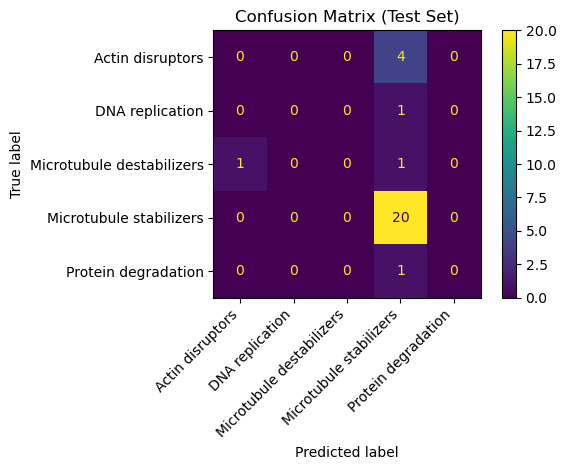

Saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\confusion_matrix_baseline.png


In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ensure Figures directory exists
FIG_DIR = os.path.join(PROJECT_ROOT, "Figures")
os.makedirs(FIG_DIR, exist_ok=True)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(values_format="d")  # shows integer counts
plt.title("Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

out_path = os.path.join(FIG_DIR, "confusion_matrix_baseline.png")
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved to:", out_path)

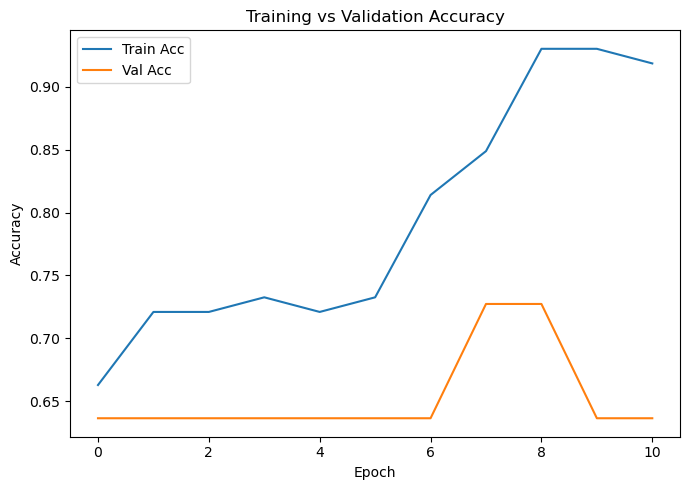

Saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\training_validation_accuracy.png


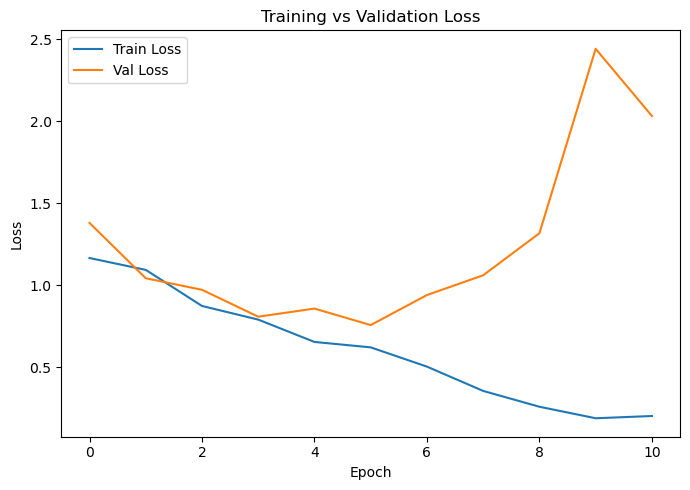

Saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\training_validation_loss.png


In [23]:
import matplotlib.pyplot as plt
import os

FIG_DIR = os.path.join(PROJECT_ROOT, "Figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Accuracy plot
plt.figure(figsize=(7,5))
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
acc_path = os.path.join(FIG_DIR, "training_validation_accuracy.png")
plt.savefig(acc_path, dpi=300)
plt.show()
print("Saved to:", acc_path)

# Loss plot
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
loss_path = os.path.join(FIG_DIR, "training_validation_loss.png")
plt.savefig(loss_path, dpi=300)
plt.show()
print("Saved to:", loss_path)